<a href="https://colab.research.google.com/github/Raymond24TI/ProbStat/blob/main/MTK_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
FILE = "/content/3TIB_06_GenzCyberResilience.xlsx"
df = pd.read_excel(FILE, sheet_name="Data")

In [36]:
print("Jumlah baris dan kolom :", df.shape)
print("Jumlah data kosong     :", df.isna().sum().sum())

Jumlah baris dan kolom : (400, 93)
Jumlah data kosong     : 0


In [37]:
butir = {"BMS": 15, "PKS": 17, "MPK": 12}
for kode, n in butir.items():
    kolom = [f"{kode}{i}" for i in range(1, n + 1)]
    df[kode] = df[kolom].mean(axis=1)
skor = ["BMS", "PKS", "MPK"]

In [38]:
def tabel_frekuensi(kolom, urutan=None):
    f = df[kolom].value_counts()
    if urutan:
        f = f.reindex(urutan)
    t = pd.DataFrame({"Frekuensi": f, "Persen (%)": (f / len(df) * 100).round(2)})
    t.loc["Total"] = [t["Frekuensi"].sum(), t["Persen (%)"].sum().round(2)]
    return t

urut_edu = ["Below High School", "High School/Equivalent", "Undergraduate", "Postgraduate"]
urut_dur = ["<1 Hour", "1-2 Hours", "2-3 Hours", "3-4 Hours", "4-5 Hours", ">5 Hours"]
for k, u in [("Gender", None), ("Education_Level", urut_edu),
             ("Main_Platform", None), ("Daily_Duration", urut_dur)]:
    print("\n", k); print(tabel_frekuensi(k, u))


 Gender
        Frekuensi  Persen (%)
Gender                       
Male        267.0       66.75
Female      133.0       33.25
Total       400.0      100.00

 Education_Level
                        Frekuensi  Persen (%)
Education_Level                              
Below High School             3.0        0.75
High School/Equivalent      311.0       77.75
Undergraduate                82.0       20.50
Postgraduate                  4.0        1.00
Total                       400.0      100.00

 Main_Platform
                Frekuensi  Persen (%)
Main_Platform                        
Instagram           241.0       60.25
YouTube              59.0       14.75
TikTok               54.0       13.50
X (Twitter)          19.0        4.75
Facebook             11.0        2.75
WhatsApp             10.0        2.50
Multi-platform        2.0        0.50
Discord               2.0        0.50
Quora                 1.0        0.25
LinkedIn              1.0        0.25
Total               400.0    

In [39]:
def ringkas(s):
    modus = s.round(4).mode()
    return pd.Series({
        "n": s.count(), "Mean": s.mean(), "Median": s.median(),
        "Modus (terkecil)": modus.min(), "Frek. modus": (s.round(4) == modus.min()).sum(),
        "Simpangan baku": s.std(), "Varians": s.var(),
        "Min": s.min(), "Q1": s.quantile(.25), "Q3": s.quantile(.75),
        "IQR": s.quantile(.75) - s.quantile(.25), "Max": s.max(),
        "Rentang": s.max() - s.min(), "Skewness": s.skew(), "Kurtosis": s.kurt()})
desk = df[skor].apply(ringkas).round(3)
print("\n", desk)


                       BMS      PKS      MPK
n                 400.000  400.000  400.000
Mean                3.019    3.629    3.166
Median              3.000    3.588    3.000
Modus (terkecil)    3.000    3.059    3.000
Frek. modus        74.000   45.000   86.000
Simpangan baku      0.807    0.588    0.786
Varians             0.651    0.346    0.618
Min                 1.000    1.471    1.000
Q1                  2.600    3.176    2.833
Q3                  3.467    4.000    3.667
IQR                 0.867    0.824    0.833
Max                 5.000    5.000    5.000
Rentang             4.000    3.529    4.000
Skewness            0.049    0.206   -0.050
Kurtosis            0.337    0.373    0.617


In [40]:
batas = [1, round(7/3, 6), round(11/3, 6), 5]
label = ["Rendah", "Sedang", "Tinggi"]
for k in skor:
    df[k + "_Kat"] = pd.cut(df[k].round(6), bins=batas, labels=label, include_lowest=True)
kat = pd.DataFrame({k: df[k + "_Kat"].value_counts().reindex(label) for k in skor})
print("\nJumlah responden per kategori\n", kat)
print("\nPersen (%)\n", (kat / len(df) * 100).round(2))


Jumlah responden per kategori
         BMS  PKS  MPK
Rendah   78    3   53
Sedang  247  221  255
Tinggi   75  176   92

Persen (%)
           BMS    PKS    MPK
Rendah  19.50   0.75  13.25
Sedang  61.75  55.25  63.75
Tinggi  18.75  44.00  23.00


In [41]:
def bandingkan(kolom, urutan=None):
    g = df.groupby(kolom)[skor].agg(["count", "mean", "median", "std"]).round(3)
    return g.reindex(urutan) if urutan else g
print("\nMenurut Gender\n", bandingkan("Gender"))
print("\nMenurut Daily_Duration\n", bandingkan("Daily_Duration", urut_dur))


Menurut Gender
          BMS                        PKS                        MPK         \
       count   mean median    std count   mean median    std count   mean   
Gender                                                                      
Female   133  2.910    3.0  0.742   133  3.550  3.471  0.574   133  3.029   
Male     267  3.074    3.0  0.833   267  3.668  3.647  0.592   267  3.235   

                      
       median    std  
Gender                
Female  3.000  0.723  
Male    3.083  0.808  

Menurut Daily_Duration
                  BMS                        PKS                        MPK  \
               count   mean median    std count   mean median    std count   
Daily_Duration                                                               
<1 Hour           15  3.053    3.0  0.866    15  3.843  3.941  0.566    15   
1-2 Hours         66  3.147    3.0  0.838    66  3.676  3.647  0.558    66   
2-3 Hours         93  2.975    3.0  0.896    93  3.679  3.588  0.60

In [42]:
bersih = df[df["Flag_VariasiRendah"] == "Tidak"]
print("\nTanpa Flag_VariasiRendah (n =", len(bersih), ")\n",
      bersih[skor].agg(["mean", "median", "std"]).round(3))


Tanpa Flag_VariasiRendah (n = 353 )
           BMS    PKS    MPK
mean    2.949  3.634  3.115
median  3.000  3.588  3.000
std     0.790  0.572  0.778


In [43]:
warna = {"BMS": "#2E75B6", "PKS": "#548235", "MPK": "#C55A11"}
nama = {"BMS": "Kesadaran (BMS)", "PKS": "Praktik (PKS)", "MPK": "Edukasi (MPK)"}

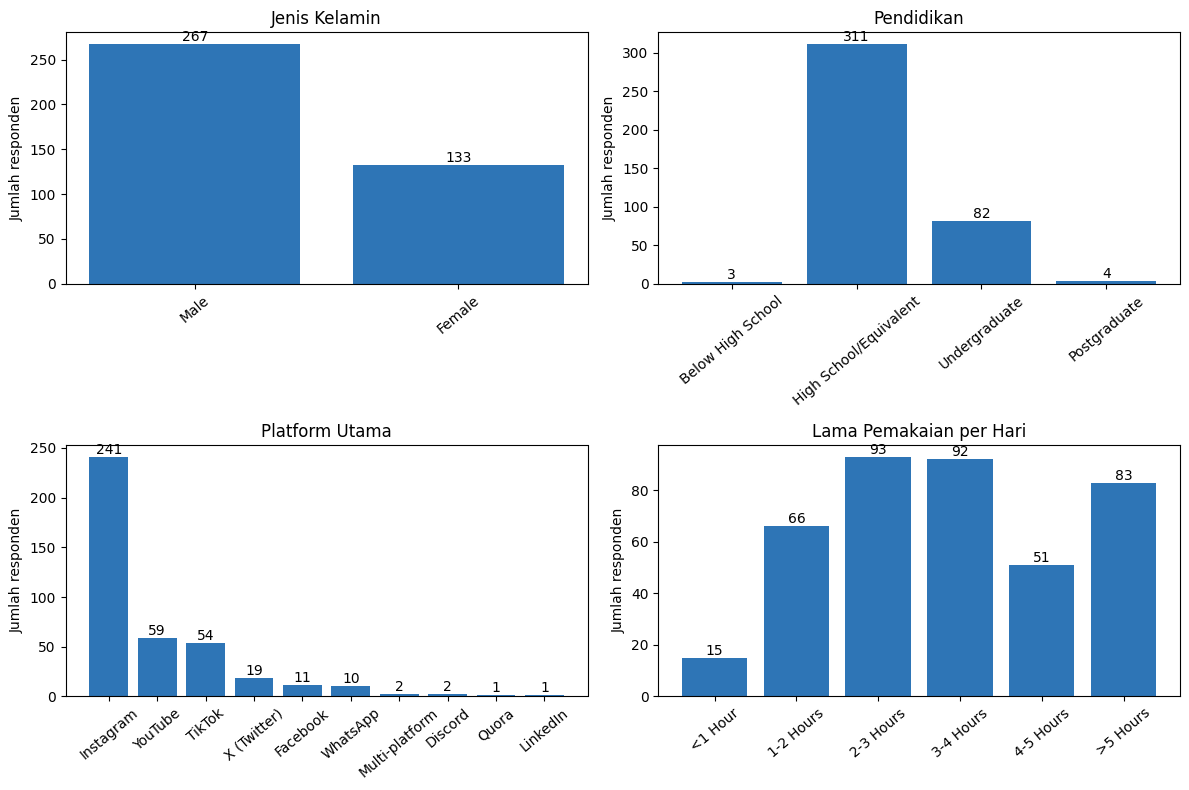

In [44]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, (k, u, jd) in zip(ax.ravel(), [("Gender", None, "Jenis Kelamin"),
        ("Education_Level", urut_edu, "Pendidikan"),
        ("Main_Platform", None, "Platform Utama"),
        ("Daily_Duration", urut_dur, "Lama Pemakaian per Hari")]):
    f = df[k].value_counts()
    f = f.reindex(u) if u else f
    bars = a.bar(f.index, f.values, color="#2E75B6")
    a.bar_label(bars)
    a.set_title(jd); a.set_ylabel("Jumlah responden")
    a.tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.savefig("gambar_4_1_karakteristik.png", dpi=150); plt.show()

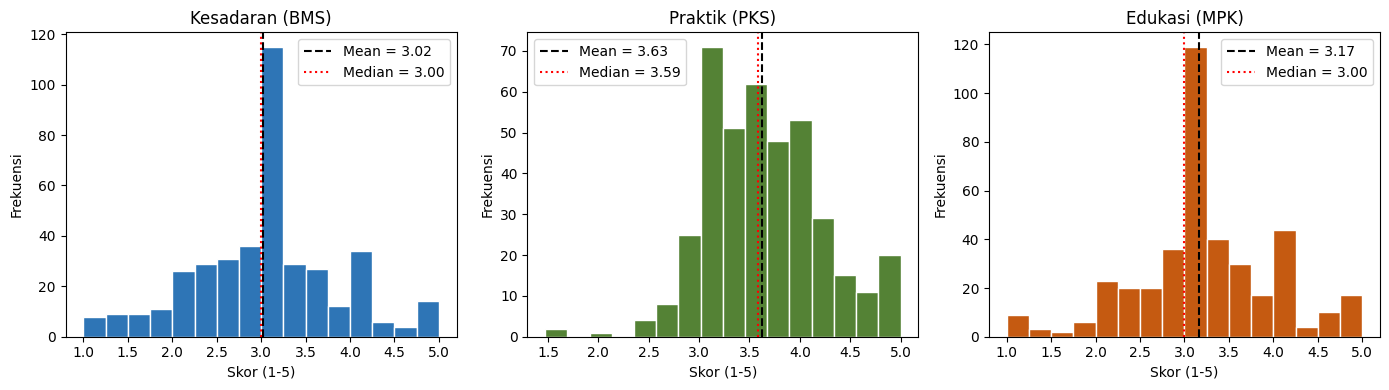

In [45]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, k in zip(ax, skor):
    a.hist(df[k], bins=16, color=warna[k], edgecolor="white")
    a.axvline(df[k].mean(), color="black", linestyle="--", label=f"Mean = {df[k].mean():.2f}")
    a.axvline(df[k].median(), color="red", linestyle=":", label=f"Median = {df[k].median():.2f}")
    a.set_title(nama[k]); a.set_xlabel("Skor (1-5)"); a.set_ylabel("Frekuensi"); a.legend()
plt.tight_layout(); plt.savefig("gambar_4_2_histogram.png", dpi=150); plt.show()

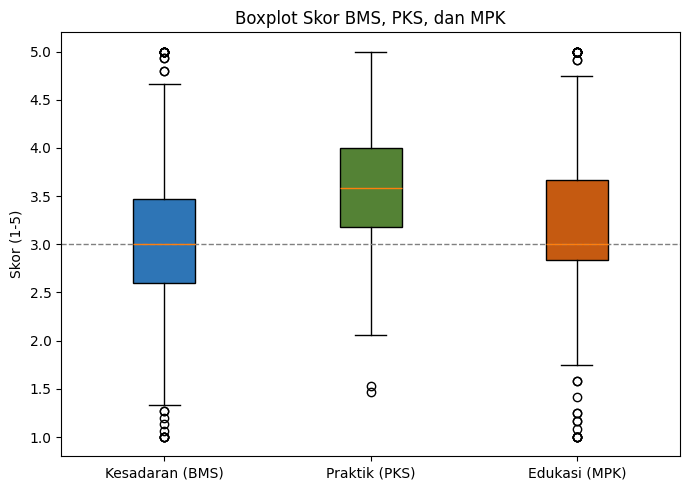

In [46]:
plt.figure(figsize=(7, 5))
bp = plt.boxplot([df[k] for k in skor], patch_artist=True)
plt.xticks([1, 2, 3], [nama[k] for k in skor])
for patch, k in zip(bp["boxes"], skor):
    patch.set_facecolor(warna[k])
plt.axhline(3, color="grey", linestyle="--", linewidth=1)
plt.ylabel("Skor (1-5)"); plt.title("Boxplot Skor BMS, PKS, dan MPK")
plt.tight_layout(); plt.savefig("gambar_4_3_boxplot.png", dpi=150); plt.show()

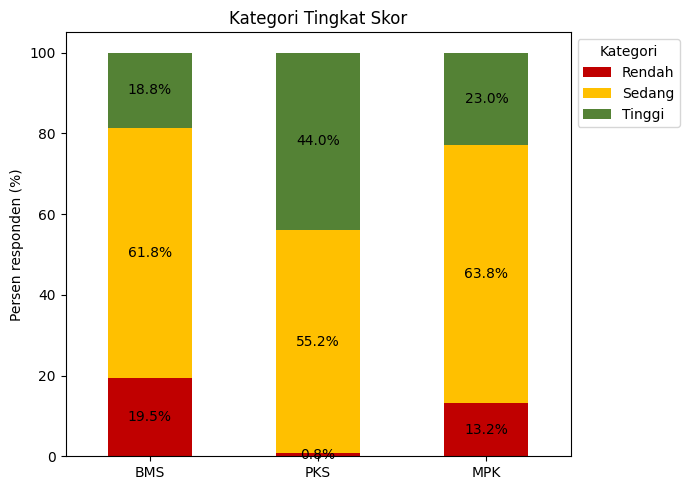

In [47]:
pers = (kat / len(df) * 100)
ax = pers.T.plot(kind="bar", stacked=True, figsize=(7, 5),
                 color=["#C00000", "#FFC000", "#548235"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center")
plt.xticks(rotation=0); plt.ylabel("Persen responden (%)")
plt.title("Kategori Tingkat Skor")
plt.legend(title="Kategori", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.savefig("gambar_4_4_kategori.png", dpi=150); plt.show()

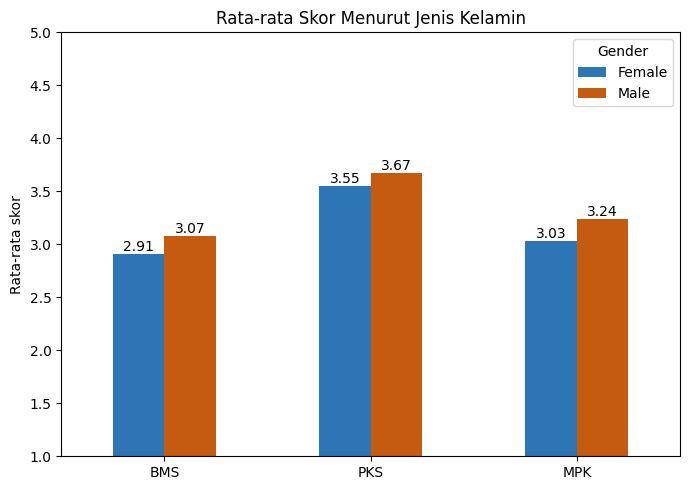

In [48]:
m = df.groupby("Gender")[skor].mean()
ax = m.T.plot(kind="bar", figsize=(7, 5), color=["#2E75B6", "#C55A11"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f")
plt.xticks(rotation=0); plt.ylim(1, 5); plt.ylabel("Rata-rata skor")
plt.title("Rata-rata Skor Menurut Jenis Kelamin"); plt.legend(title="Gender")
plt.tight_layout(); plt.savefig("gambar_4_5_gender.png", dpi=150); plt.show()

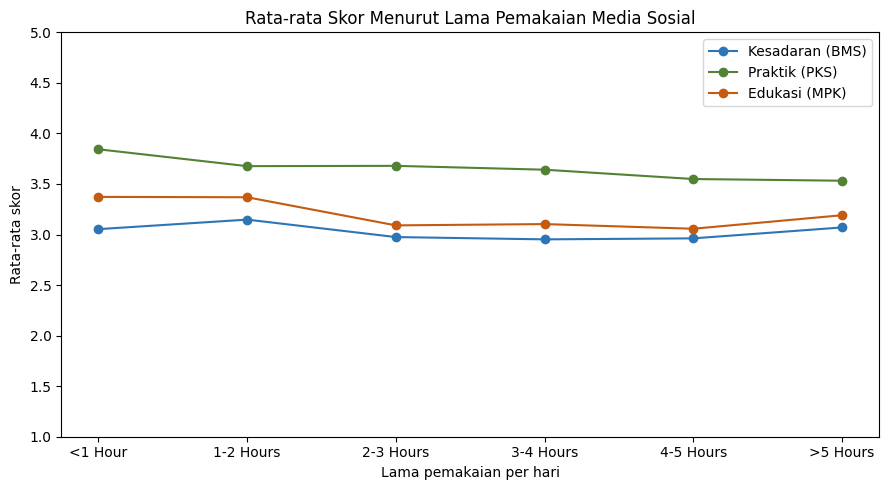

In [49]:
m = df.groupby("Daily_Duration")[skor].mean().reindex(urut_dur)
plt.figure(figsize=(9, 5))
for k in skor:
    plt.plot(m.index, m[k], marker="o", color=warna[k], label=nama[k])
plt.ylim(1, 5); plt.ylabel("Rata-rata skor"); plt.xlabel("Lama pemakaian per hari")
plt.title("Rata-rata Skor Menurut Lama Pemakaian Media Sosial"); plt.legend()
plt.tight_layout(); plt.savefig("gambar_4_6_durasi.png", dpi=150); plt.show()